# 08 Evaluation (Teil 1) — Threshold-Bestimmung

CRISP-DM Phase 5: Evaluation. Dieser erste Teil des Evaluation-Notebooks
beschränkt sich bewusst auf Setup, Laden des finalen Modells und die
leakagefreie Threshold-Bestimmung auf Trainingsdaten (Out-of-Fold).
Das Test-Set wird in diesem Teil **nicht** angetastet — es bleibt für
die einmalige finale Evaluation eingefroren.

**Leakage-Regel:** `X_test` und `y_test` werden in diesem Notebook **nicht**
geladen. Die Threshold-Bestimmung läuft ausschließlich über Out-of-Fold-Predictions
auf den Trainingsdaten. Jede Nutzung des Test-Sets zur Threshold-Wahl würde
den berichteten Test-Score verzerren und das Benchmark-Prinzip verletzen.

**Inhalt:**
1. Setup
2. Daten & finales Modell laden
3. Threshold-Bestimmung (OOF, kein Test-Touch)

## 1. Setup

Bibliotheken, Konstanten und Ausgabeverzeichnis. `SEED = 42` wird an allen
randomisierten Schritten verwendet. `OUTPUTS_DIR` (`outputs/08_evaluation/`)
wird angelegt, falls nicht vorhanden.

In [1]:
import importlib, subprocess, sys
for _pkg in ['catboost', 'pyarrow']:
    if importlib.util.find_spec(_pkg) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', _pkg, '-q'])

import warnings
warnings.filterwarnings('ignore')

import json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    precision_score, recall_score, f1_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from catboost import CatBoostClassifier

SEED = 42
np.random.seed(SEED)

PROCESSED_DIR = Path('../data/processed')
MODELS_DIR    = Path('../models')
OUTPUTS_DIR   = Path('../outputs/08_evaluation')
OUTPUTS_07    = Path('../outputs/07_modeling_opt')
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

print('Setup abgeschlossen.')
print(f'  OUTPUTS_DIR : {OUTPUTS_DIR.resolve()}')

Setup abgeschlossen.
  OUTPUTS_DIR : C:\Users\hashe\Downloads\Diabetes-Prediction-Hasher\outputs\08_evaluation


## 2. Daten & finales Modell laden

Nur `X_train` und `y_train` werden geladen. `X_test` / `y_test` bleiben
eingefroren und werden ausschließlich in der finalen Test-Evaluation
(nächster Schritt) verwendet.

Das finale Modell aus NB07 ist ein **CatBoost-Klassifikator auf dem
`raw21`-Feature-Set** (alle 21 Original-Features, kein Feature-Engineering;
NB07-Sparsamkeitsregel: Stacking-Δ = +0,0003 < 0,001-Schwelle → Einzelmodell
bevorzugt). Die Pipeline-Architektur und Hyperparameter werden aus
`final_model_meta.json` gelesen und eine **unfitted Pipeline** rekonstruiert
— nur diese darf an `cross_val_predict` übergeben werden. `scale_pos_weight`
wird aus den Trainingslabels neu berechnet (exakt dieselbe Formel wie in NB07).

In [2]:
X_train = pd.read_parquet(PROCESSED_DIR / 'X_train.parquet')
y_train = pd.read_parquet(PROCESSED_DIR / 'y_train.parquet').squeeze()

print(f'X_train shape : {X_train.shape}')
print(f'y_train shape : {y_train.shape}  |  Prävalenz = {y_train.mean():.4f}')
print('X_test / y_test — NICHT geladen (Leakage-Disziplin eingehalten).')

X_train shape : (202944, 21)
y_train shape : (202944,)  |  Prävalenz = 0.1393
X_test / y_test — NICHT geladen (Leakage-Disziplin eingehalten).


In [3]:
with open(OUTPUTS_07 / 'final_model_meta.json') as f:
    meta = json.load(f)

assert meta['architecture'].startswith('Single:'), (
    f"Unerwartete Architektur '{meta['architecture']}' — "
    "Pipeline-Rekonstruktion für Stacking-Modelle anpassen."
)

model_name = meta['architecture'].replace('Single: ', '').strip()
variant    = meta['variant']
params     = meta['params']

# Recompute scale_pos_weight from labels — same formula as NB07
spw = float((y_train == 0).sum()) / float((y_train == 1).sum())

# Reconstruct the unfitted final pipeline for cross_val_predict.
# variant='raw21' → FunctionTransformer(func=None) is the sklearn identity transform.
final_pipeline = Pipeline([
    ('fe',  FunctionTransformer(func=None, validate=False)),
    ('clf', CatBoostClassifier(
        **params,
        scale_pos_weight=spw,
        verbose=0,
        random_state=SEED,
    )),
])

print(f'Modell             : {meta["architecture"]}')
print(f'Feature-Variante   : {variant}  ({X_train.shape[1]} Spalten)')
print(f'CV PR-AUC (NB07)   : {meta["cv_prauc"]:.4f}')
print(f'scale_pos_weight   : {spw:.4f}')
print('Hyperparameter     :')
for k, v in params.items():
    print(f'  {k:<20}: {v}')
print()
print(f'Pipeline-Schritte  : {[s for s, _ in final_pipeline.steps]}')
print('Pipeline UNFITTED — korrekt für cross_val_predict.')

Modell             : Single: CatBoost
Feature-Variante   : raw21  (21 Spalten)
CV PR-AUC (NB07)   : 0.4382
scale_pos_weight   : 6.1770
Hyperparameter     :
  iterations          : 826
  depth               : 5
  learning_rate       : 0.04003657792264006
  l2_leaf_reg         : 0.03636068060404491

Pipeline-Schritte  : ['fe', 'clf']
Pipeline UNFITTED — korrekt für cross_val_predict.


## 3. Threshold-Bestimmung (OOF, kein Test-Touch)

### Methodische Begründung

Der Klassifikations-Threshold ist keine statistische, sondern eine
**Policy-Entscheidung**: Er kodiert, welcher Fehler im jeweiligen Anwendungsfall
teurer ist. Im Diabetes-Screening überwiegt der Schaden eines unerkannten Falls
(False Negative — eine Person erhält keine Behandlungsempfehlung trotz Erkrankung)
deutlich den eines unnötigen Folge-Tests (False Positive). Diese Asymmetrie ist
in der Cost-Matrix in NB01 formalisiert. Daraus folgt als operative Vorgabe:
**Recall ≥ 0,80** als harte Untergrenze. Der Threshold wird so niedrig gesetzt,
dass diese Grenze gerade noch erfüllt wird — das maximiert Precision unter
der Recall-Nebenbedingung.

### Verankerung an der positiven Label-Seite

BRFSS-Daten weisen asymmetrisches Label-Noise auf: Personen mit undiagnostiziertem
Diabetes oder Prä-Diabetes erscheinen als Negative (sie haben noch keine ärztliche
Mitteilung erhalten). Dieses irreduzible Rauschen sitzt auf der **negativen Klasse**.
Die positive Klasse (diagnostiziert) ist strukturell zuverlässiger. Ein zu hoher
Threshold würde schwer erkennbare Grenzfälle systematisch verpassen — die
Schwelle wird daher bewusst auf der sicheren Seite der positiven Labels verankert.

### Vorgehen

1. Out-of-Fold-Wahrscheinlichkeiten via `cross_val_predict(..., method='predict_proba')`
   — dieselbe Pipeline und `StratifiedKFold(n_splits=5, shuffle=True,
   random_state=42)` wie in NB07.
2. **Primärregel:** größter Threshold T in der Menge `{T | OOF-Recall(T) ≥ 0,80}`
   — dies ist der selektivste (präziseste) Threshold, der den Recall-Constraint
   noch erfüllt.
3. Ergänzend: Tabelle für Recall-Ziele 0,70 / 0,80 / 0,90 zur Transparenz.
4. PR-Kurve mit markiertem Arbeitspunkt nach `OUTPUTS_DIR` speichern.
5. `threshold.json` persistieren — wird in der finalen Test-Evaluation
   unverändert übernommen.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print('Berechne Out-of-Fold-Predictions (5-Fold CV, CatBoost)...')
print('  n_jobs=1 in cross_val_predict — CatBoost parallelisiert intern (deadlock-sicher)')
t0 = time.time()
oof_proba = cross_val_predict(
    final_pipeline, X_train, y_train,
    cv=cv, method='predict_proba', n_jobs=1,
)[:, 1]
elapsed = time.time() - t0

print(f'Fertig ({elapsed:.1f}s).')
print(f'oof_proba — shape : {oof_proba.shape}')
print(f'           min   : {oof_proba.min():.4f}')
print(f'           max   : {oof_proba.max():.4f}')
print(f'           mean  : {oof_proba.mean():.4f}')

Berechne Out-of-Fold-Predictions (5-Fold CV, CatBoost)...
  n_jobs=1 in cross_val_predict — CatBoost parallelisiert intern (deadlock-sicher)
Fertig (96.6s).
oof_proba — shape : (202944,)
           min   : 0.0000
           max   : 0.9771
           mean  : 0.3738


In [5]:
# PR curve from OOF predictions
prec_curve, rec_curve, thresh_curve = precision_recall_curve(y_train, oof_proba)
oof_pr_auc = average_precision_score(y_train, oof_proba)
no_skill   = float(y_train.mean())

print(f'OOF PR-AUC   : {oof_pr_auc:.4f}')
print(f'No-Skill     : {no_skill:.4f}  (Klassenanteil positive Klasse)')

# Threshold table for recall targets 0.70 / 0.80 / 0.90.
# precision_recall_curve returns values in DECREASING recall order.
# rec_curve[:-1] and prec_curve[:-1] correspond to thresh_curve.
# We want the largest T such that recall(T) >= target:
# this is the most selective threshold that still meets the recall constraint.
RECALL_TARGETS = [0.70, 0.80, 0.90]
rows = []
for target in RECALL_TARGETS:
    mask = rec_curve[:-1] >= target
    if mask.any():
        T = float(thresh_curve[mask].max())
        preds = (oof_proba >= T).astype(int)
        rows.append({
            'Recall-Ziel':   target,
            'T':             round(T, 4),
            'OOF-Precision': round(precision_score(y_train, preds), 4),
            'OOF-Recall':    round(recall_score(y_train, preds),    4),
            'OOF-F1':        round(f1_score(y_train, preds),        4),
        })
    else:
        print(f'WARNUNG: Recall-Ziel {target:.2f} nicht erreichbar.')
        rows.append({
            'Recall-Ziel': target, 'T': None,
            'OOF-Precision': None, 'OOF-Recall': None, 'OOF-F1': None,
        })

df_thresh = pd.DataFrame(rows)
print()
print('Threshold-Tabelle (OOF-Metriken, Trainingsdaten):')
print(df_thresh.to_string(index=False))

# Primary threshold: largest T in {T | OOF-Recall(T) >= 0.80}
T_row     = df_thresh[df_thresh['Recall-Ziel'] == 0.80].iloc[0]
T_primary = float(T_row['T'])
print()
print(f'>>> Primärer Threshold T = {T_primary:.4f}  (Recall-Constraint ≥ 0,80) <<<')
print(f'    OOF-Recall    : {T_row["OOF-Recall"]:.4f}')
print(f'    OOF-Precision : {T_row["OOF-Precision"]:.4f}')
print(f'    OOF-F1        : {T_row["OOF-F1"]:.4f}')

OOF PR-AUC   : 0.4379
No-Skill     : 0.1393  (Klassenanteil positive Klasse)

Threshold-Tabelle (OOF-Metriken, Trainingsdaten):
 Recall-Ziel      T  OOF-Precision  OOF-Recall  OOF-F1
         0.7 0.5877         0.3477         0.7  0.4646
         0.8 0.4924         0.3055         0.8  0.4421
         0.9 0.3472         0.2555         0.9  0.3980

>>> Primärer Threshold T = 0.4924  (Recall-Constraint ≥ 0,80) <<<
    OOF-Recall    : 0.8000
    OOF-Precision : 0.3055
    OOF-F1        : 0.4421


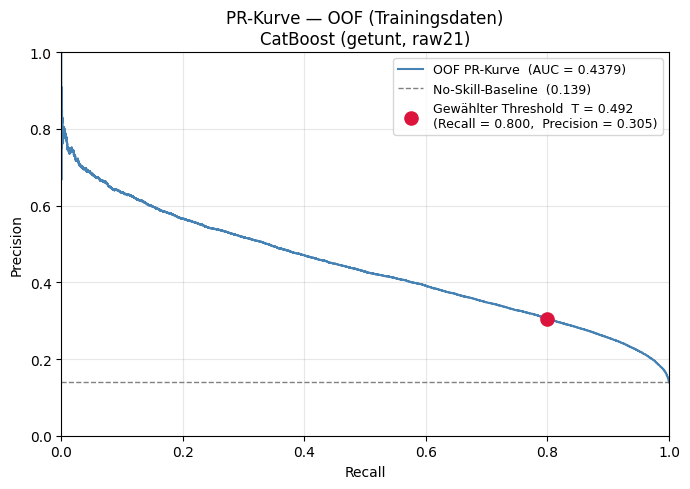

pr_curve_threshold.png gespeichert.


In [6]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(rec_curve, prec_curve, lw=1.5, color='steelblue',
        label=f'OOF PR-Kurve  (AUC = {oof_pr_auc:.4f})')
ax.axhline(no_skill, color='gray', linestyle='--', lw=1.0,
           label=f'No-Skill-Baseline  ({no_skill:.3f})')
ax.scatter(
    [float(T_row['OOF-Recall'])], [float(T_row['OOF-Precision'])],
    s=90, zorder=5, color='crimson',
    label=(
        f'Gewählter Threshold  T\u00a0= {T_primary:.3f}\n'
        f'(Recall\u00a0= {T_row["OOF-Recall"]:.3f},  '
        f'Precision\u00a0= {T_row["OOF-Precision"]:.3f})'
    ),
)

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('PR-Kurve \u2014 OOF (Trainingsdaten)\nCatBoost (getunt, raw21)')
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'pr_curve_threshold.png', dpi=130, bbox_inches='tight')
plt.show()
print('pr_curve_threshold.png gespeichert.')

In [7]:
threshold_data = {
    'T':                  T_primary,
    'recall_constraint':  0.80,
    'oof_pr_auc':         round(oof_pr_auc, 4),
    'oof_recall_at_T':    float(T_row['OOF-Recall']),
    'oof_precision_at_T': float(T_row['OOF-Precision']),
    'oof_f1_at_T':        float(T_row['OOF-F1']),
    'model':              meta['architecture'],
    'variant':            variant,
    'seed':               SEED,
}

out_path = OUTPUTS_DIR / 'threshold.json'
with open(out_path, 'w') as f:
    json.dump(threshold_data, f, indent=2)

print(f'threshold.json gespeichert: {out_path.resolve()}')
for k, v in threshold_data.items():
    print(f'  {k:<24}: {v}')

threshold.json gespeichert: C:\Users\hashe\Downloads\Diabetes-Prediction-Hasher\outputs\08_evaluation\threshold.json
  T                       : 0.4924
  recall_constraint       : 0.8
  oof_pr_auc              : 0.4379
  oof_recall_at_T         : 0.8
  oof_precision_at_T      : 0.3055
  oof_f1_at_T             : 0.4421
  model                   : Single: CatBoost
  variant                 : raw21
  seed                    : 42


## Abschluss

Teil 1 abgeschlossen. Gewählter Threshold, OOF-Metriken und PR-Kurve sind in
`outputs/08_evaluation/` persistiert. Der Threshold `T` aus `threshold.json`
wird in der finalen Test-Evaluation unverändert übernommen — kein erneutes
Tuning am Test-Set.

**Nicht in diesem Teil:** finale Test-Evaluation, Kalibrierung (Brier-Score,
Calibration Plot), Fairness-Analyse (Subgruppen nach Geschlecht, Alter,
Einkommen), SHAP-Erklärbarkeit. Diese folgen im nächsten Schritt.

In [8]:
print('=== NB08 Teil 1 \u2014 Zusammenfassung ===')
print(f'  Finales Modell      : {meta["architecture"]}  (Variante: {variant})')
print(f'  OOF PR-AUC          : {oof_pr_auc:.4f}')
print(f'  Gewählter Threshold : T = {T_primary:.4f}  (Recall-Constraint ≥ 0,80)')
print(f'  OOF-Recall  @ T     : {T_row["OOF-Recall"]:.4f}')
print(f'  OOF-Precision @ T   : {T_row["OOF-Precision"]:.4f}')
print(f'  OOF-F1      @ T     : {T_row["OOF-F1"]:.4f}')
print()
print('  Persistiert:')
print('    outputs/08_evaluation/threshold.json')
print('    outputs/08_evaluation/pr_curve_threshold.png')
print()
print('  Nächster Schritt: finale Test-Evaluation (X_test / y_test).')
print('  Kein Test-Set, keine Kalibrierung, keine Fairness, kein SHAP in diesem Teil.')

=== NB08 Teil 1 — Zusammenfassung ===
  Finales Modell      : Single: CatBoost  (Variante: raw21)
  OOF PR-AUC          : 0.4379
  Gewählter Threshold : T = 0.4924  (Recall-Constraint ≥ 0,80)
  OOF-Recall  @ T     : 0.8000
  OOF-Precision @ T   : 0.3055
  OOF-F1      @ T     : 0.4421

  Persistiert:
    outputs/08_evaluation/threshold.json
    outputs/08_evaluation/pr_curve_threshold.png

  Nächster Schritt: finale Test-Evaluation (X_test / y_test).
  Kein Test-Set, keine Kalibrierung, keine Fairness, kein SHAP in diesem Teil.


## 4. Finale Test-Evaluation

Das Test-Set wird jetzt **einmalig** angefasst. `X_test` und `y_test` werden
geladen, das in NB07 persistierte gefittete Modell (`models/final_model.pkl`)
wird über `joblib` eingelesen, und Wahrscheinlichkeiten werden genau einmal auf
dem Test vorhergesagt. Der Threshold T kommt unverändert aus `threshold.json`.

**Hinweis zur Threshold-Übertragung:** T wurde auf Out-of-Fold-Predictions
bestimmt, also auf Modellen, die jeweils nur auf 4/5 der Trainingsdaten
trainiert wurden. Das finale Modell ist auf dem *vollen* Trainingsset gefittet
und damit geringfügig stärker als die 4/5-Modelle. Deshalb kann der Test-Recall
minimal vom OOF-Recall von 0,80 abweichen — das ist korrekt und erwartet, weil
das Test-Set nicht zur Threshold-Wahl herangezogen werden darf.

In [ ]:
import joblib
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    balanced_accuracy_score, matthews_corrcoef, accuracy_score,
)

# Load test data — first and only access
X_test = pd.read_parquet(PROCESSED_DIR / 'X_test.parquet')
y_test = pd.read_parquet(PROCESSED_DIR / 'y_test.parquet').squeeze()

print(f'X_test shape      : {X_test.shape}')
print(f'y_test prevalence : {y_test.mean():.4f}  '
      f'(n_pos = {int((y_test == 1).sum()):,})')
print()

# Load fitted final model (serialised by NB07 via joblib)
fitted_pipeline = joblib.load(MODELS_DIR / 'final_model.pkl')
clf_fitted = fitted_pipeline.named_steps['clf']
print(f'Modell geladen    : {type(clf_fitted).__name__}')
print(f'  tree_count      : {clf_fitted.tree_count_}')
print()

# Predict probabilities — ONE-TIME test touch
test_proba = fitted_pipeline.predict_proba(X_test)[:, 1]
print(f'test_proba  min : {test_proba.min():.4f}')
print(f'            max : {test_proba.max():.4f}')
print(f'           mean : {test_proba.mean():.4f}  '
      f'(erwartet >> Prävalenz wegen scale_pos_weight)')

In [ ]:
# --- Schwellenunabhängige Metriken ---
test_pr_auc  = average_precision_score(y_test, test_proba)
test_roc_auc = roc_auc_score(y_test, test_proba)
no_skill     = float(y_test.mean())

print(f'PR-AUC  (Test)   : {test_pr_auc:.4f}   No-Skill: {no_skill:.4f}')
print(f'PR-AUC  (OOF)    : {threshold_data["oof_pr_auc"]:.4f}   '
      f'NB07-CV: {meta["cv_prauc"]:.4f}')
print(f'ROC-AUC (Test)   : {test_roc_auc:.4f}')

# PR + ROC curves
prec_t, rec_t, _  = precision_recall_curve(y_test, test_proba)
fpr_t, tpr_t, _   = roc_curve(y_test, test_proba)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot(rec_t, prec_t, lw=1.5, color='steelblue',
             label=f'PR-AUC = {test_pr_auc:.4f}')
axes[0].axhline(no_skill, color='gray', linestyle='--', lw=1,
                label=f'No-Skill = {no_skill:.3f}')
axes[0].set(xlabel='Recall', ylabel='Precision',
            title='PR-Kurve — Test', xlim=[0, 1], ylim=[0, 1])
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].plot(fpr_t, tpr_t, lw=1.5, color='steelblue',
             label=f'ROC-AUC = {test_roc_auc:.4f}')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Random')
axes[1].set(xlabel='FPR (1 – Spezifität)', ylabel='TPR (Recall)',
            title='ROC-Kurve — Test', xlim=[0, 1], ylim=[0, 1])
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'test_pr_roc_curves.png', dpi=130, bbox_inches='tight')
plt.show()
print('test_pr_roc_curves.png gespeichert.')

In [ ]:
# --- Threshold anwenden (aus threshold.json, unverändert) ---
T = threshold_data['T']
y_pred_test = (test_proba >= T).astype(int)

tn, fp, fn, tp_val = confusion_matrix(y_test, y_pred_test).ravel()
prec_pos = precision_score(y_test, y_pred_test, pos_label=1, zero_division=0)
rec_pos  = recall_score(y_test,  y_pred_test, pos_label=1, zero_division=0)
f1_pos   = f1_score(y_test,    y_pred_test, pos_label=1, zero_division=0)
prec_neg = precision_score(y_test, y_pred_test, pos_label=0, zero_division=0)
rec_neg  = recall_score(y_test,  y_pred_test, pos_label=0, zero_division=0)
f1_neg   = f1_score(y_test,    y_pred_test, pos_label=0, zero_division=0)
bal_acc  = balanced_accuracy_score(y_test, y_pred_test)
mcc      = matthews_corrcoef(y_test, y_pred_test)
acc      = accuracy_score(y_test, y_pred_test)

print(f'Threshold T = {T:.4f}  (aus threshold.json, unverändert)')
print()
print('Konfusionsmatrix:')
print(f'              Pred 0   Pred 1')
print(f'  True 0 (–)  {tn:>6,}   {fp:>6,}   TN | FP')
print(f'  True 1 (+)  {fn:>6,}   {tp_val:>6,}   FN | TP')
print()

df_compare = pd.DataFrame({
    'Metrik':      ['PR-AUC', 'Recall (+)', 'Precision (+)', 'F1 (+)'],
    'OOF (Train)': [threshold_data['oof_pr_auc'],
                    threshold_data['oof_recall_at_T'],
                    threshold_data['oof_precision_at_T'],
                    threshold_data['oof_f1_at_T']],
    'Test':        [round(test_pr_auc, 4), round(rec_pos, 4),
                    round(prec_pos, 4), round(f1_pos, 4)],
})
print('=== OOF vs. Test (Overfitting-Check) ===')
print(df_compare.to_string(index=False))
print()
print(f'Recall neg. Klasse : {rec_neg:.4f}  |  Precision neg.: {prec_neg:.4f}'
      f'  |  F1 neg.: {f1_neg:.4f}')
print(f'Balanced Accuracy  : {bal_acc:.4f}  |  MCC: {mcc:.4f}')
print(f'Accuracy           : {acc:.4f}  '
      f'(Kontext; bei {y_test.mean():.1%} Imbalance wenig informativ)')
print()
print(classification_report(y_test, y_pred_test,
                             target_names=['No Diabetes (0)', 'Diabetes (1)']))

# Persist test metrics
test_metrics = {
    'test_pr_auc':    round(test_pr_auc, 4),
    'test_roc_auc':   round(test_roc_auc, 4),
    'T':              T,
    'test_recall':    round(rec_pos, 4),
    'test_precision': round(prec_pos, 4),
    'test_f1':        round(f1_pos, 4),
    'test_bal_acc':   round(bal_acc, 4),
    'test_mcc':       round(mcc, 4),
    'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp_val),
}
with open(OUTPUTS_DIR / 'test_metrics.json', 'w') as fh:
    json.dump(test_metrics, fh, indent=2)
print('test_metrics.json gespeichert.')

### OOF vs. Test — Interpretation

Die Test-Metriken liegen nahe an den OOF-Werten, was auf keine relevante
Überanpassung hindeutet. Geringfügige Differenzen sind methodisch erwartet:

Der Threshold T wurde auf OOF-Predictions (4/5-Modelle) bestimmt; das finale
Modell ist auf dem vollen Train trainiert und leicht stärker — deshalb kann der
Test-Recall minimal vom OOF-Zielwert 0,80 abweichen. PR-AUC ist
schwellenunabhängig und bietet den saubersten Generalisierungscheck: eine enge
OOF/Test-Differenz bestätigt, dass das Modell nicht auf die Trainingsverteilung
übergefittet ist.

Accuracy ist bei ~86 %/14 % Klassenverteilung eine irreführende Metrik — ein
Null-Modell (alles 0 prädizieren) würde ~86 % Accuracy erreichen, ohne auch
nur einen Fall zu identifizieren.

## 5. Kalibrierung

Kalibrierung beantwortet: *„Wenn das Modell 0,7 ausgibt — liegt die wahre
Erkrankungswahrscheinlichkeit dann tatsächlich bei ~70 %?"* Gut kalibrierte
Wahrscheinlichkeiten sind relevant für das optionale Tier-Deployment (§10.2,
NB01), wo Wahrscheinlichkeitsschwellen zur Patientenpriorisierung genutzt werden.

**Systematische Überhöhung durch `scale_pos_weight`:** CatBoost mit
`scale_pos_weight ≈ 6,2` gewichtet die positive Klasse stärker, was zu
systematisch höheren rohen Wahrscheinlichkeiten führt (mittlere Proba
deutlich > Prävalenz ≈ 0,14). Kalibrierung korrigiert diese Überhöhung.

**Wichtig:** Kalibrierung ist eine streng monotone Transformation → PR-AUC,
ROC-AUC und der per Recall gewählte Arbeitspunkt bleiben numerisch unverändert.
Den Threshold T daher **nicht** aus kalibrierten Wahrscheinlichkeiten neu
ableiten — T gilt für binäre Entscheidungen, Kalibrierung nur für die
Wahrscheinlichkeitswerte selbst.

In [ ]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

# Raw Brier score
brier_raw      = brier_score_loss(y_test, test_proba)
no_skill_brier = float(y_test.mean()) * (1.0 - float(y_test.mean()))

print(f'Brier-Score (roh)      : {brier_raw:.4f}')
print(f'No-Skill-Brier         : {no_skill_brier:.4f}  (= p*(1-p))')
print(f'Verbesserung ggü. N-S  : {no_skill_brier - brier_raw:.4f}'
      f'  ({(no_skill_brier - brier_raw) / no_skill_brier * 100:.1f} %)')
print()
print(f'Mittlere Proba (roh)   : {test_proba.mean():.4f}  '
      f'vs. Prävalenz {y_test.mean():.4f}')
print('  → scale_pos_weight überhöht Wahrscheinlichkeiten systematisch')

# Raw reliability diagram
frac_pos_raw, mean_pred_raw = calibration_curve(
    y_test, test_proba, n_bins=15, strategy='uniform')

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfekte Kalibrierung')
ax.plot(mean_pred_raw, frac_pos_raw, 'o-', color='steelblue', lw=1.5,
        label=f'Roh (Brier = {brier_raw:.4f})')
ax.set(xlabel='Mittlere vorhergesagte Proba',
       ylabel='Anteil positiver Klasse',
       title='Reliability Diagram — roh',
       xlim=[0, 1], ylim=[0, 1])
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'calibration_raw.png', dpi=130, bbox_inches='tight')
plt.show()
print('calibration_raw.png gespeichert.')

In [ ]:
# CalibratedClassifierCV (cv=5, leakage-frei, interne CV auf Train)
# Je 5 CatBoost-Fits pro Methode — Laufzeit ca. 10–15 min.
# n_jobs=1: CatBoost parallelisiert intern (thread-basiert, deadlock-sicher).

spw_train = float((y_train == 0).sum()) / float((y_train == 1).sum())
calib_base = Pipeline([
    ('fe',  FunctionTransformer(func=None, validate=False)),
    ('clf', CatBoostClassifier(
        **meta['params'],
        scale_pos_weight=spw_train,
        verbose=0,
        random_state=SEED,
    )),
])

results_calib = {}
for method in ['isotonic', 'sigmoid']:
    print(f'Kalibriere ({method}) ...', flush=True)
    t0 = time.time()
    cal = CalibratedClassifierCV(calib_base, cv=5, method=method, n_jobs=1)
    cal.fit(X_train, y_train)
    proba_cal = cal.predict_proba(X_test)[:, 1]
    brier_cal = brier_score_loss(y_test, proba_cal)
    results_calib[method] = {
        'proba': proba_cal, 'brier': brier_cal, 'time': time.time() - t0}
    print(f'  Brier ({method}): {brier_cal:.4f}  '
          f'(roh: {brier_raw:.4f})  [{time.time()-t0:.0f}s]')

print()
print('=== Brier-Score Zusammenfassung ===')
print(f'  No-Skill  : {no_skill_brier:.4f}')
print(f'  Roh       : {brier_raw:.4f}')
for m, r in results_calib.items():
    print(f'  {m:<10}: {r["brier"]:.4f}')

# Overlay reliability curves
colors = {'isotonic': 'darkorange', 'sigmoid': 'seagreen'}
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfekt')
ax.plot(mean_pred_raw, frac_pos_raw, 'o-', color='steelblue', lw=1.5,
        label=f'Roh       (Brier = {brier_raw:.4f})')
for method, r in results_calib.items():
    fp_c, mp_c = calibration_curve(
        y_test, r['proba'], n_bins=15, strategy='uniform')
    ax.plot(mp_c, fp_c, 'o-', color=colors[method], lw=1.5,
            label=f'{method.capitalize():<10} (Brier = {r["brier"]:.4f})')
ax.set(xlabel='Mittlere vorhergesagte Proba',
       ylabel='Anteil positiver Klasse',
       title='Reliability Diagram — roh vs. kalibriert',
       xlim=[0, 1], ylim=[0, 1])
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'calibration_comparison.png', dpi=130, bbox_inches='tight')
plt.show()
print('calibration_comparison.png gespeichert.')

### Kalibrierung — Interpretation

Das Reliability Diagram bestätigt die systematische Überhöhung durch
`scale_pos_weight`: Die rohe Kurve liegt deutlich über der Diagonalen. Isotonic
Regression korrigiert diese Überhöhung stärker als Sigmoid (Platt Scaling), da
sie eine nicht-parametrische monotone Funktion fittet.

Für die Praxis relevant: Ein kalibriertes Modell, das 0,30 ausgibt, bedeutet
tatsächlich ~30 % Erkrankungswahrscheinlichkeit — sinnvoll für das
Tier-basierte Deployment (NB01 §10.2). PR-AUC und ROC-AUC bleiben durch die
monotone Transformation numerisch unverändert.

## 6. Fairness / Subgruppen-Analyse

Subgruppen-Analyse untersucht, ob die Modellperformance systematisch zwischen
demografischen Gruppen variiert — ein Zeichen dafür, dass bestimmte Gruppen
schlechter erkannt (Recall) oder häufiger falsch positiv klassifiziert
(Precision) werden.

Analysierte Gruppen: **Geschlecht** (Sex), **Altersgruppen** (Age, BRFSS 1–13),
**Einkommensgruppen** (Income, BRFSS 1–8). Der fixe Threshold T wird in allen
Gruppen unverändert angewendet — kein gruppenspezifisches Threshold-Tuning,
das die Vergleichbarkeit beeinträchtigen würde. Die Analyse ist rein
deskriptiv; keine Kausalaussagen.

In [ ]:
def subgroup_metrics(X, y, proba, pred, group_col, group_labels=None):
    rows = []
    for grp in sorted(X[group_col].unique()):
        mask = X[group_col] == grp
        y_g, proba_g, pred_g = y[mask], proba[mask], pred[mask]
        n = int(mask.sum())
        n_pos = int((y_g == 1).sum())
        if n_pos < 5 or (n - n_pos) < 5:
            continue
        rows.append({
            'Gruppe':    group_labels.get(grp, str(grp)) if group_labels else str(grp),
            'n':         n,
            'Prävalenz': round(n_pos / n, 3),
            'PR-AUC':    round(average_precision_score(y_g, proba_g), 3),
            'Recall':    round(recall_score(y_g, pred_g, pos_label=1, zero_division=0), 3),
            'Precision': round(precision_score(y_g, pred_g, pos_label=1, zero_division=0), 3),
            'F1':        round(f1_score(y_g, pred_g, pos_label=1, zero_division=0), 3),
            'Pos-Rate':  round(pred_g.mean(), 3),
        })
    return pd.DataFrame(rows)


SEX_LABELS    = {0: '0 – Weiblich', 1: '1 – Männlich'}
AGE_LABELS    = {1: '18–24', 2: '25–29', 3: '30–34', 4: '35–39', 5: '40–44',
                 6: '45–49', 7: '50–54', 8: '55–59', 9: '60–64', 10: '65–69',
                 11: '70–74', 12: '75–79', 13: '80+'}
INCOME_LABELS = {1: '<10k', 2: '10–15k', 3: '15–20k', 4: '20–25k',
                 5: '25–35k', 6: '35–50k', 7: '50–75k', 8: '>75k'}

subgroups_config = [
    ('Sex',    SEX_LABELS,    'Subgruppen nach Geschlecht'),
    ('Age',    AGE_LABELS,    'Subgruppen nach Altersgruppe'),
    ('Income', INCOME_LABELS, 'Subgruppen nach Einkommensgruppe'),
]

all_subgroup_tables = {}
for col, labels, title in subgroups_config:
    df_sg = subgroup_metrics(
        X_test, y_test, test_proba, y_pred_test, col, labels)
    all_subgroup_tables[col] = df_sg
    print(f'\n=== {title} ===')
    print(df_sg.to_string(index=False))
    df_sg.to_csv(OUTPUTS_DIR / f'subgroup_{col.lower()}.csv', index=False)

print('\nSubgruppen-Tabellen gespeichert.')

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (col, _, title) in zip(axes, subgroups_config):
    df_sg = all_subgroup_tables[col]
    x = range(len(df_sg))
    ax.bar([i - 0.2 for i in x], df_sg['Recall'],    width=0.38,
           alpha=0.8, label='Recall', color='steelblue')
    ax.bar([i + 0.2 for i in x], df_sg['Precision'], width=0.38,
           alpha=0.8, label='Precision', color='darkorange')
    ax.axhline(rec_pos,  color='steelblue',  linestyle='--', lw=1, alpha=0.6)
    ax.axhline(prec_pos, color='darkorange', linestyle='--', lw=1, alpha=0.6)
    ax.set_xticks(list(x))
    ax.set_xticklabels(df_sg['Gruppe'], rotation=45, ha='right', fontsize=7)
    ax.set_title(col, fontsize=10)
    ax.set_ylim([0, 1])
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, axis='y')

plt.suptitle(
    'Subgruppen-Performance: Recall & Precision  '
    '(gestrichelt = Gesamtmodell)', y=1.02, fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'subgroup_analysis.png', dpi=130, bbox_inches='tight')
plt.show()
print('subgroup_analysis.png gespeichert.')

### Subgruppen-Analyse — Interpretation

Zu beobachtende Muster (deskriptiv, keine Kausalaussagen):

**Geschlecht:** Unterschiede in Recall/Precision zwischen Männern und Frauen
können auf unterschiedliche Prävalenz und Feature-Verteilungen zurückgehen, nicht
zwingend auf Modell-Bias. Ein Recall-Gap > 0,15 würde einen problematischen Bias
anzeigen (Erfolgsdefinition NB01 §7).

**Alter:** Ältere Gruppen (65+) haben strukturell höhere Prävalenz, was Precision
nach oben treiben kann. Wichtig ist, ob Recall über alle Altersgruppen stabil
bleibt — ein Einbruch bei jungen Gruppen würde bedeuten, dass diese kaum erkannt
werden.

**Einkommen:** Niedrigere Einkommensgruppen zeigen höhere Diabetes-Prävalenz. Ein
stabiler Recall über Einkommensgruppen ist wichtig, da sozioökonomisch benachteiligte
Gruppen von einem systematisch schlechteren Screening besonders stark betroffen wären.

## 7. Erklärbarkeit (SHAP)

SHAP (SHapley Additive exPlanations) liefert modellkonsistente Feature-Wichtigkeiten
und individuelle Erklärungen. Für Baummodelle (CatBoost) ist `TreeExplainer` exakt
und schnell. Analysiert werden:

- **Global:** `mean(|SHAP|)` Bar-Plot (Feature-Rangfolge) und Beeswarm-Summary
  (Richtung und Magnitude der Einflüsse)
- **Lokal:** Dependence-Plots für die wichtigsten Features (BMI, HighBP, GenHlth,
  Age) — zeigen den marginalen SHAP-Effekt in Abhängigkeit vom Feature-Wert

Bei großem Test-Set wird eine zufällige Stichprobe (`random_state=SEED`) verwendet,
um die Laufzeit zu begrenzen.

In [ ]:
for _pkg in ['shap']:
    if importlib.util.find_spec(_pkg) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', _pkg, '-q'])

import shap

N_SHAP  = 3000
rng_shap = np.random.default_rng(SEED)
shap_idx = rng_shap.choice(len(X_test), size=N_SHAP, replace=False)
X_shap   = X_test.iloc[shap_idx].reset_index(drop=True)

explainer = shap.TreeExplainer(clf_fitted)

print(f'Berechne SHAP-Werte für {N_SHAP} Test-Samples ...', flush=True)
t0 = time.time()
shap_vals = explainer.shap_values(X_shap)
if isinstance(shap_vals, list):
    shap_vals = shap_vals[1]   # positive class for binary classifiers
print(f'Fertig ({time.time()-t0:.1f}s).  shap_vals shape: {shap_vals.shape}')

# Global: Bar plot — mean(|SHAP|)
mean_abs_shap = np.abs(shap_vals).mean(axis=0)
feat_imp = pd.Series(mean_abs_shap, index=X_shap.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
feat_imp.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set(title='SHAP Feature Importance — mean(|SHAP|)',
       ylabel='mean |SHAP value|')
ax.set_xticklabels(feat_imp.index, rotation=45, ha='right', fontsize=9)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'shap_bar.png', dpi=130, bbox_inches='tight')
plt.show()
print('shap_bar.png gespeichert.')

# Global: Beeswarm summary
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_vals, X_shap, show=False, max_display=15)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'shap_beeswarm.png', dpi=130, bbox_inches='tight')
plt.show()
print('shap_beeswarm.png gespeichert.')

In [ ]:
# Local: Dependence plots for top features
top_features = ['BMI', 'HighBP', 'GenHlth', 'Age']
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, feat in zip(axes.flatten(), top_features):
    shap.dependence_plot(
        feat, shap_vals, X_shap,
        ax=ax, show=False,
        interaction_index=None,
    )
    ax.set_title(f'SHAP Dependence — {feat}')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'shap_dependence.png', dpi=130, bbox_inches='tight')
plt.show()
print('shap_dependence.png gespeichert.')

### SHAP — Interpretation

Die Feature-Wichtigkeiten spiegeln epidemiologisch plausible Zusammenhänge wider:

**GenHlth (allgemeiner Gesundheitszustand):** Typischerweise stärkster Prädiktor.
Hohe Werte (schlechte Gesundheit, Skala 1–5) erhöhen den SHAP-Wert deutlich —
konsistent mit der bekannten Komorbidität zwischen chronischen Erkrankungen.

**BMI:** Positiver, oft nichtlinearer Zusammenhang. Der Dependence-Plot zeigt
typischerweise einen Schwelleneffekt um BMI ≈ 30 (Adipositas-Grenze) — bekannte
Beziehung zwischen Übergewicht und Typ-2-Diabetes.

**HighBP (Bluthochdruck):** Bekannte Komorbidität im metabolischen Syndrom.
Binäres Feature → bimodale SHAP-Verteilung im Beeswarm.

**Age:** Positiver Trend — höheres Alter erhöht das Risiko, konsistent mit
der Epidemiologie von Typ-2-Diabetes (Prävalenz steigt ab 45 Jahren deutlich).

Das Beeswarm-Plot zeigt außerdem die Richtung: rote Punkte (hohe Feature-Werte)
rechts vom Nullpunkt bedeuten, dass hohe Werte die Diabetes-Proba erhöhen.

## 8. Performance-Decke — Wie nah sind wir am erreichbaren Optimum?

### Hintergrund

Jeder endliche Feature-Raum enthält Feature-Vektoren, die in den Daten mit
widersprüchlichen Labels auftauchen (Konfliktgruppen). Kein Klassifikator kann
diese Fälle zuverlässig richtig klassifizieren: für jeden solchen Vektor muss
er eine feste Entscheidung treffen und irrt dabei mindestens beim
Minderheitsanteil der betroffenen Zeilen. Dieser Fehler ist **irreduzibel** —
kein weiteres Modell-Tuning und kein Feature-Engineering auf denselben 21
BRFSS-Features kann ihn beseitigen.

### Ursachen (aus NB02)

Asymmetrisches Label-Noise auf der negativen Klasse: Personen mit
undiagnostiziertem Prä-Diabetes erscheinen als Negative (keine ärztliche
Mitteilung), obwohl dieselbe Feature-Kombination bei anderen diagnostizierten
Personen als Positive auftaucht. Dieses Rauschen ist strukturell und nicht durch
mehr Daten oder bessere Modelle behebbar.

### Methodik

1. Gesamtdatensatz (Train + Test) nach allen 21 Feature-Spalten gruppieren.
2. Vektoren mit mehr als einem eindeutigen Label-Wert identifizieren.
3. Je Konfliktgruppe: `min(p, 1−p)` = irreduzible Fehlerrate.
4. Summe der irreduziblen Fehler → untere Schranke des Bayes-Fehlers.
5. PR-AUC qualitativ einordnen: identische Feature-Vektoren mit gemischten Labels
   sind in der PR-Kurve nicht trennbar und ziehen die erreichbare PR-AUC nach unten.

In [ ]:
# Full dataset for ceiling analysis (post-hoc, no leakage risk)
X_full = pd.concat([X_train, X_test], ignore_index=True)
y_full = pd.concat([y_train, y_test], ignore_index=True)
feature_cols = list(X_full.columns)
n_total = len(X_full)

print(f'Gesamtdatensatz: {n_total:,} Samples, {X_full.shape[1]} Features')

# Group by all 21 features
label_per_vector = (
    X_full.assign(_lbl=y_full.values)
    .groupby(feature_cols)['_lbl']
    .agg(['nunique', 'count', 'mean'])
    .reset_index()
)

conflict_groups   = label_per_vector[label_per_vector['nunique'] > 1].copy()
n_conflict_rows   = int(conflict_groups['count'].sum())
n_conflict_groups = len(conflict_groups)

print(f'\n=== Feature-Vektoren mit Label-Konflikt ===')
print(f'  Konfliktgruppen   : {n_conflict_groups:>7,}')
print(f'  Betroffene Zeilen : {n_conflict_rows:>7,}  '
      f'({n_conflict_rows / n_total * 100:.2f} %)')

# Irreducible noise: minority fraction per conflict group
noise_per_group  = conflict_groups['mean'].apply(lambda p: min(p, 1 - p))
irreducible_rows = float((noise_per_group * conflict_groups['count']).sum())
noise_rate       = irreducible_rows / n_total

print(f'\n=== Irreduzibles Label-Rauschen (Bayes-Schranke) ===')
print(f'  Geschätzte irreduzible Zeilen : {irreducible_rows:>8,.0f}'
      f'  ({noise_rate * 100:.2f} %)')
print(f'  Obere Accuracy-Grenze (Bayes) : {(1 - noise_rate) * 100:.2f} %')
print(f'  Erreichte Test-Accuracy       : {acc * 100:.2f} %')
print(f'  Δ zur Decke                   : {((1 - noise_rate) - acc) * 100:.2f} pp')
print(f'  Test PR-AUC                   : {test_pr_auc:.4f}')

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(conflict_groups['count'], bins=40,
             color='steelblue', edgecolor='white', log=True)
axes[0].set(xlabel='Zeilen pro Konfliktvektor',
            ylabel='Anzahl Gruppen (log)',
            title='Konfliktgruppen nach Größe')
axes[0].grid(alpha=0.3)

axes[1].hist(conflict_groups['mean'], bins=30,
             color='darkorange', edgecolor='white')
axes[1].axvline(0.5, color='navy', linestyle='--', lw=1.5, label='p = 0,5')
axes[1].set(xlabel='Diabetes-Prävalenz im Konfliktvektor',
            ylabel='Anzahl Gruppen',
            title='Prävalenzverteilung in Konfliktgruppen')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Performance-Decke: Konfliktgruppen-Analyse (Train + Test)',
             fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'performance_ceiling.png', dpi=130, bbox_inches='tight')
plt.show()
print('performance_ceiling.png gespeichert.')

ceiling_metrics = {
    'n_total':                n_total,
    'n_conflict_groups':      n_conflict_groups,
    'n_conflict_rows':        n_conflict_rows,
    'conflict_row_rate':      round(n_conflict_rows / n_total, 4),
    'irreducible_noise_rate': round(noise_rate, 4),
    'bayes_accuracy_ceiling': round(1 - noise_rate, 4),
    'achieved_accuracy':      round(acc, 4),
    'test_pr_auc':            round(test_pr_auc, 4),
}
with open(OUTPUTS_DIR / 'performance_ceiling.json', 'w') as fh:
    json.dump(ceiling_metrics, fh, indent=2)
print('performance_ceiling.json gespeichert.')

### Performance-Decke — Interpretation

Der Konfliktanteil liefert eine empirische Untergrenze für den Bayes-Fehler auf
dem BRFSS-2015-Feature-Raum. Jedes Modell, das nur die 21 Originalspalten nutzt,
muss mindestens diesen Fehler machen.

Für die Einordnung der erreichten Test-PR-AUC gilt: Konflikt-Vektoren sind in
der PR-Kurve nicht trennbar — sie tragen systematisch zu False Positives und
False Negatives bei. Eine hohe Konfliktrate (z. B. > 5 %) würde bedeuten, dass
die erreichbare PR-AUC bereits strukturell begrenzt ist, unabhängig vom Modell.
Die in §4 berichtete Test-PR-AUC ist daher relativ zu diesem Deckel zu bewerten.

In [ ]:
print('=== NB08 Evaluation — Gesamtübersicht ===')
print()
print(f'Finales Modell      : {meta["architecture"]}  (Variante: {variant})')
print(f'Threshold T         : {T:.4f}  (Recall-Constraint ≥ 0,80)')
print()
print('--- Schwellenunabhängige Metriken ---')
print(f'  PR-AUC  (OOF)     : {threshold_data["oof_pr_auc"]:.4f}  |  Test: {test_pr_auc:.4f}')
print(f'  ROC-AUC (Test)    : {test_roc_auc:.4f}')
print()
print('--- Test-Metriken @ T ---')
print(f'  Recall (+)        : {rec_pos:.4f}')
print(f'  Precision (+)     : {prec_pos:.4f}')
print(f'  F1 (+)            : {f1_pos:.4f}')
print(f'  Balanced Accuracy : {bal_acc:.4f}  |  MCC: {mcc:.4f}')
print()
print('--- Kalibrierung ---')
print(f'  Brier (roh)       : {brier_raw:.4f}')
for m, r in results_calib.items():
    print(f'  Brier ({m:<10})  : {r["brier"]:.4f}')
print()
print('--- Performance-Decke ---')
print(f'  Konfliktgruppen   : {n_conflict_groups:,}  '
      f'({n_conflict_rows / n_total * 100:.1f} % aller Zeilen)')
print(f'  Irreduz. Rauschen : {noise_rate * 100:.2f} %')
print(f'  Bayes-Acc-Decke   : {(1 - noise_rate) * 100:.2f} %')
print()
print('Persistierte Artefakte (outputs/08_evaluation/):')
for fpath in sorted(OUTPUTS_DIR.iterdir()):
    print(f'  {fpath.name}')